In [1]:
import numpy as np
import pandas as pd
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client
from collections import defaultdict
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt
from pystp import STPClient
import json

In [2]:
stp = STPClient()
stp.connect()

	****************************************
	*   Welcome to the Southern California *
	*      Earthquake Data Center          *
	*     Seismic Transfer Program         *
        ****************************************

Please use the following citation:
 SCEDC (2013): Southern California Earthquake Data Center.
 Caltech.Dataset. doi:10.7909/C3WD3xH
to cite data downloaded from the SCEDC.

If you use a SCEDC waveform dataset that contains data with
network codes other than 'CI', please cite the network and
its DOI. Use https://fdsn.org/networks/ to find the network
code and its corresponding DOI.

For large downloads, please consider trying the SCEDC AWS Public Dataset:
https://scedc.caltech.edu/data/cloud.html




In [3]:
# get cwd
import os
print(os.getcwd())
# read in all .png files in ../../SKHASH/tests/hash3_sk/OUT_worked
png_files = [f for f in os.listdir('../../SKHASH/tests/hash3_sk/OUT_worked')
             if f.endswith('.png')]
event_ids = [int(f.split('.')[0]) for f in png_files]

/home/vay3059/desktop/SURG-Mars/project/data


In [4]:
event_id = 2155068
# stp.get_events(evids=[event_id])
catalog = stp.get_events(evids=event_ids)
events = catalog.events
events

[Event:	1994-03-22T13:07:33.582000Z | +34.224, -118.603 | 2.3  ML

	 resource_id: ResourceIdentifier(id="2155068")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements,
 Event:	1994-02-15T04:10:52.009000Z | +34.227, -118.608 | 1.96 Mc

	 resource_id: ResourceIdentifier(id="3152388")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements,
 Event:	1994-02-10T04:19:26.019000Z | +34.237, -118.620 | 2.5  ML

	 resource_id: ResourceIdentifier(id="3150936")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements,
 Event:	1994-03-24T11:23:51.506000Z | +34.224, -118.607 | 1.74 Mc

	 resource_id: ResourceIdentifier(id="3160206")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements,
 Event:	1994-02-08T02:07:08.810000Z | +34.231, -118.598 | 2.61 ML

	 resource_id: ResourceIdentifier(id="3150490")
	  event_type: 'earthquak

In [5]:
str(events[0].resource_id)

'2155068'

In [6]:
# get waveform metadata for each event
wmd_dict = {}
for event in events:
    wmd_dict[str(event.resource_id)] = stp.get_eavail(event.resource_id, format='l', as_list=True)

In [8]:
# save to json file
with open('all_wmd.json', 'w') as f:
    json.dump(wmd_dict, f, indent=4)

In [120]:
# test_id = event_ids[0]
# test_stations = wmd_dict[str(test_id)]
# test_station = test_stations[5]

# waveforms = stp.get_trig(test_id, net=test_station[0], sta=test_station[1], chan=test_station[2])
# # print(waveforms[test_id])
# # len(list(waveforms.items())[0][1]) # length of the stream

# # now check the length of every stream produced for unique stations
# test_success = []
# for idx, sta_chan in enumerate(test_stations):
#     # if idx % 10 == 0:
#     #     print(f"Station {idx}/{len(test_stations)}")
#     waveform = stp.get_trig(test_id, net=sta_chan[0], sta=sta_chan[1], chan=sta_chan[2])
#     if len(waveform[test_id]) != 0:
#         test_success.append(sta_chan)

# sta_chan

In [7]:
wmd_success_dict = {}
for id in event_ids:
    success_stations = []
    for sta_chan in wmd_dict[str(id)]:
        try:
            waveform = stp.get_trig(id, net=sta_chan[0], sta=sta_chan[1])
        except:
            continue
        if len(waveform[id]) != 0:
            success_stations.append(sta_chan)
    wmd_success_dict[str(id)] = success_stations

Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform traces
Processed 0 waveform

: 

: 

In [137]:
# wmd_success_dict -- pick the key with the most successful stations and plot the waveforms for that event
max_stations = 0
best_event_id = None
# get distribution of number of successful stations across all events
station_counts = []

for id, stations in wmd_success_dict.items():
    station_counts.append(len(stations))
    if len(stations) > max_stations:
        max_stations = len(stations)
        best_event_id = id

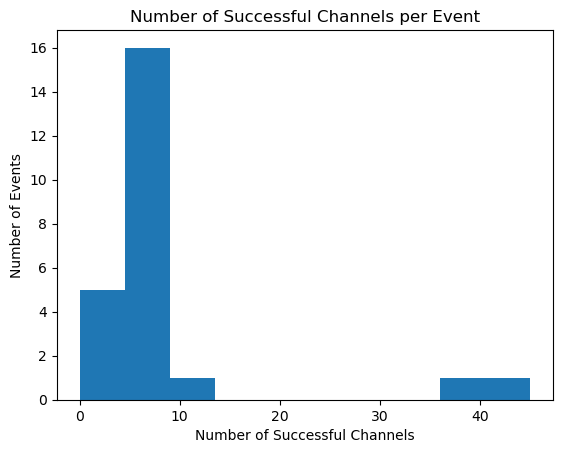

In [163]:
# station_counts histogram
plt.hist(station_counts, bins=10)
plt.xlabel('Number of Successful Channels')
plt.ylabel('Number of Events')
plt.title('Number of Successful Channels per Event')
plt.show()

In [156]:
test_stations = wmd_success_dict[best_event_id]
test_id = int(best_event_id)
print(f"Best event ID: {test_id} with {len(test_stations)} channels")

Best event ID: 3146815 with 45 channels


In [159]:
unique_stations = set()
for station in test_stations:
    unique_stations.add(station[1])
unique_stations

{'CALB',
 'CMB',
 'GSC',
 'ISA',
 'MLAC',
 'MLL',
 'PAS',
 'PFO',
 'RPV',
 'RUN',
 'SBC',
 'SBK',
 'SVD',
 'SWM',
 'USC',
 'VG2',
 'VTV',
 'WAS'}

In [162]:
grouped_stations = defaultdict(list)
for station in test_stations:
    grouped_stations[station[1]].append(station)
grouped_stations

with open('success_case_study.json', 'w') as f:
    json.dump(grouped_stations, f, indent=3)

Processed 1 waveform traces


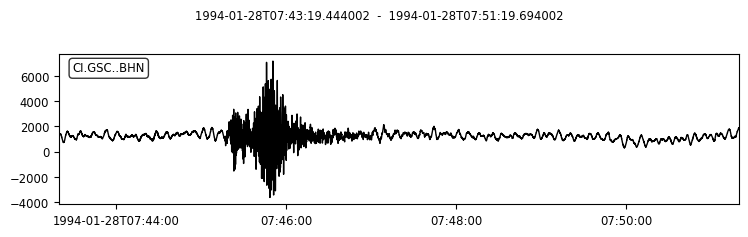

Processed 1 waveform traces


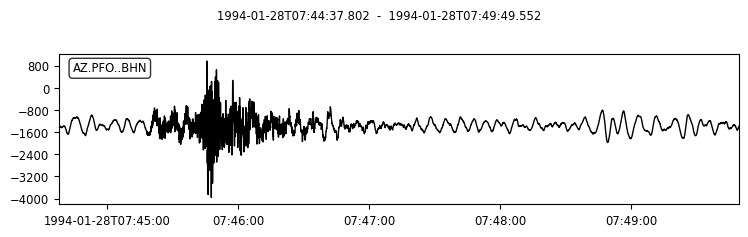

Processed 1 waveform traces


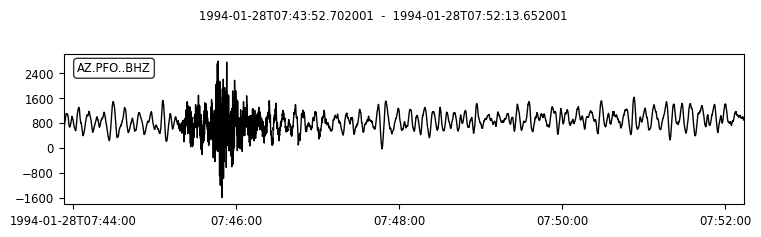

Processed 0 waveform traces
Processed 1 waveform traces


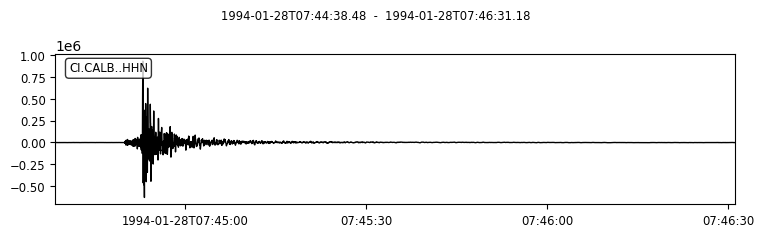

Processed 1 waveform traces


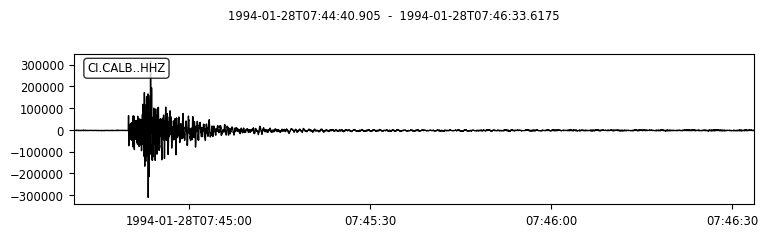

Processed 1 waveform traces


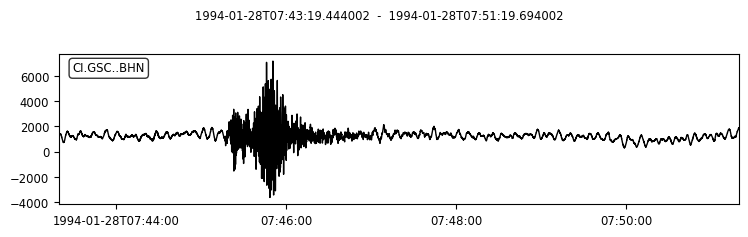

Processed 1 waveform traces


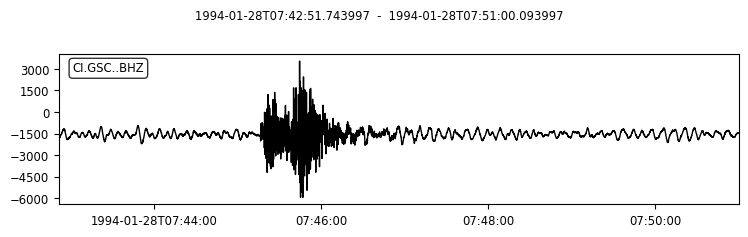

Processed 0 waveform traces
Processed 1 waveform traces


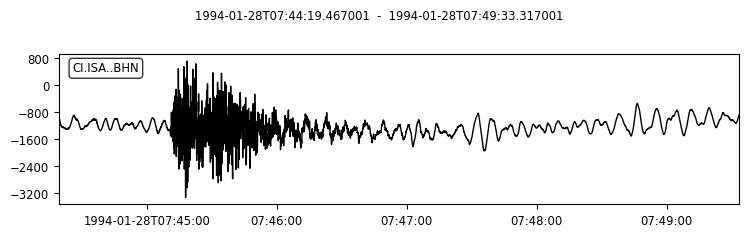

Processed 1 waveform traces


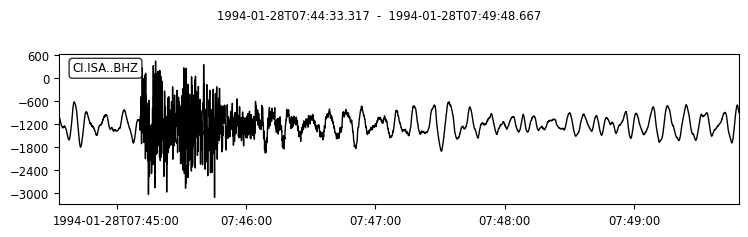

Processed 0 waveform traces
Processed 1 waveform traces


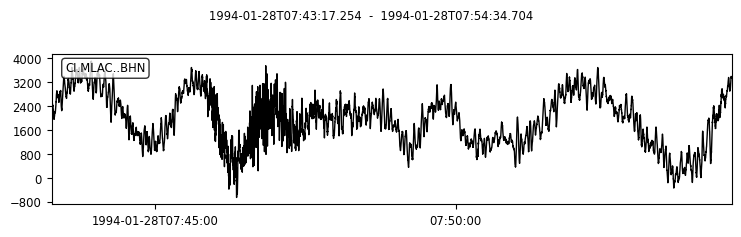

Processed 1 waveform traces


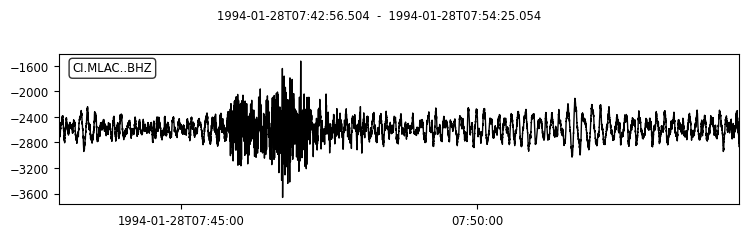

Processed 1 waveform traces


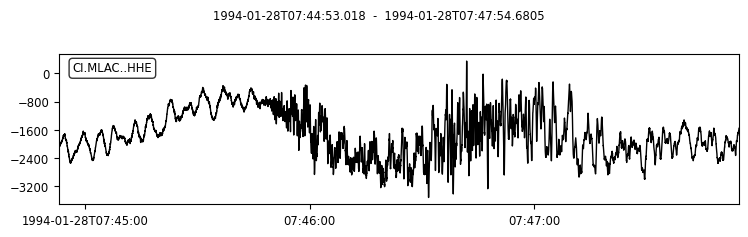

Processed 1 waveform traces


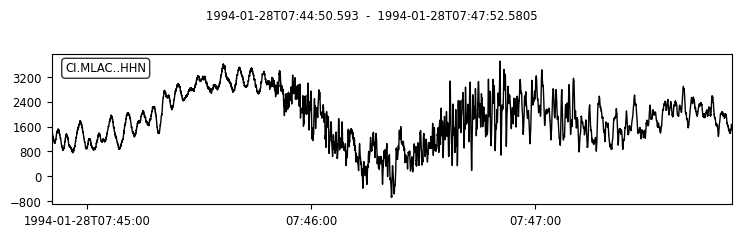

Processed 1 waveform traces


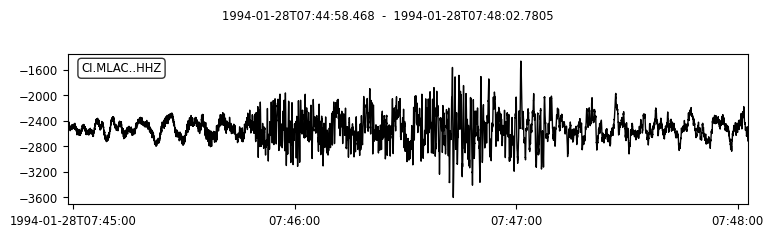

Processed 0 waveform traces
Processed 1 waveform traces


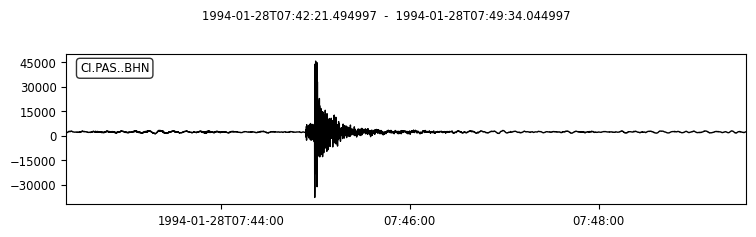

Processed 1 waveform traces


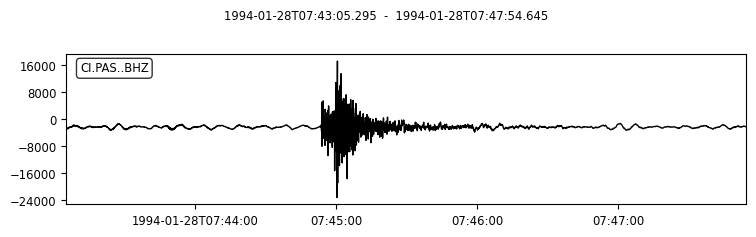

Processed 0 waveform traces
Processed 1 waveform traces


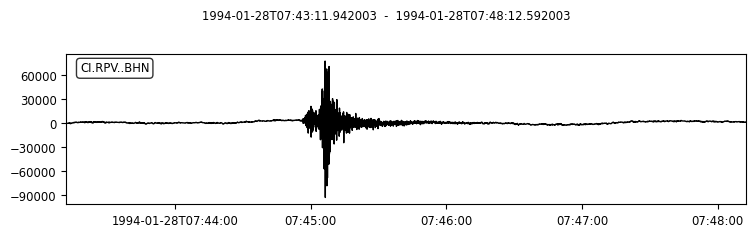

Processed 1 waveform traces


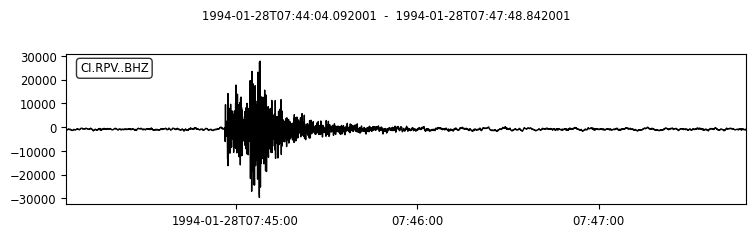

Processed 1 waveform traces


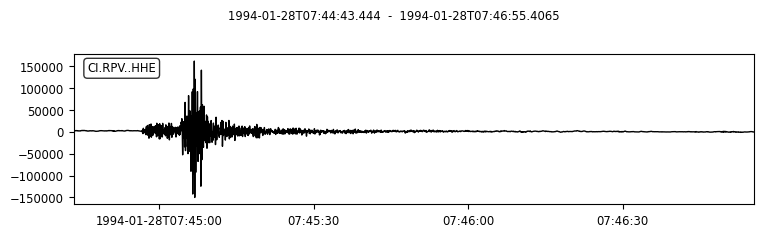

Processed 1 waveform traces


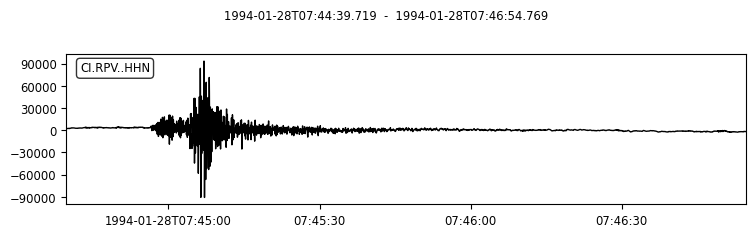

Processed 1 waveform traces


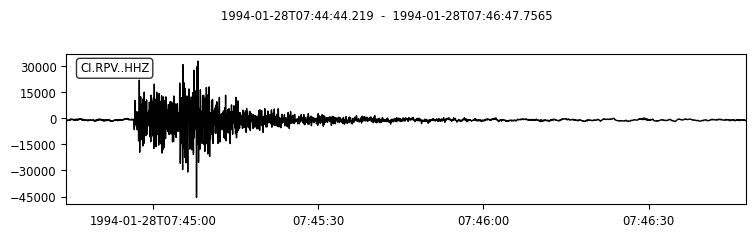

Processed 0 waveform traces
Processed 1 waveform traces


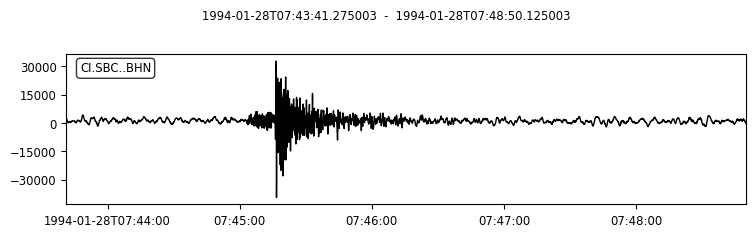

Processed 1 waveform traces


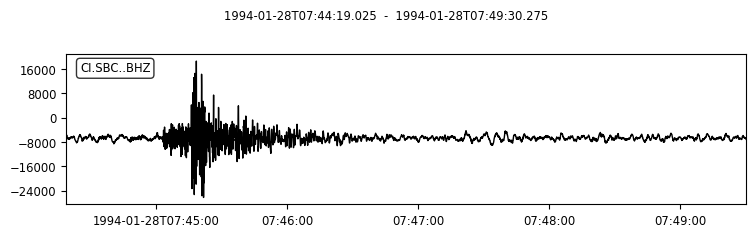

Processed 0 waveform traces
Processed 1 waveform traces


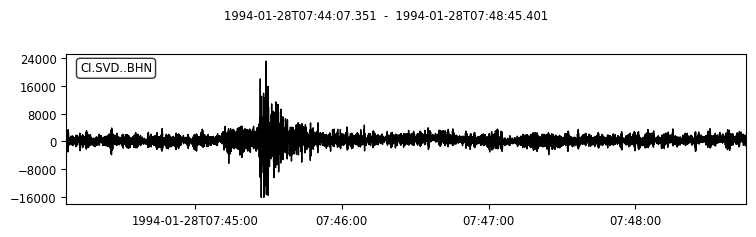

Processed 1 waveform traces


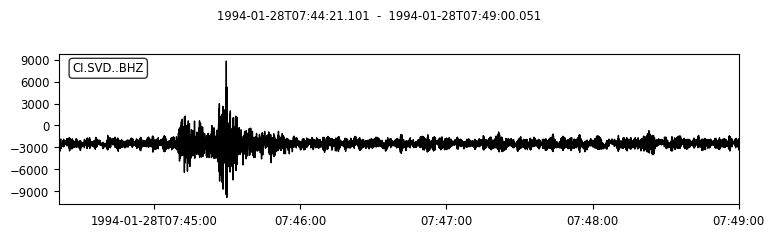

Processed 0 waveform traces
Processed 1 waveform traces


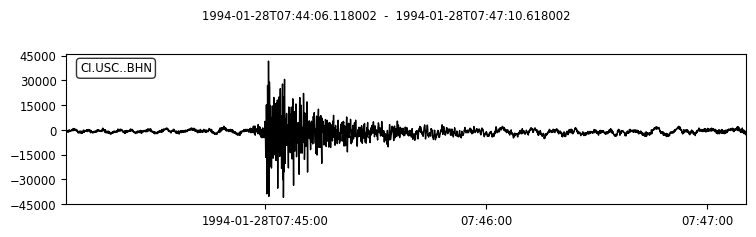

Processed 1 waveform traces


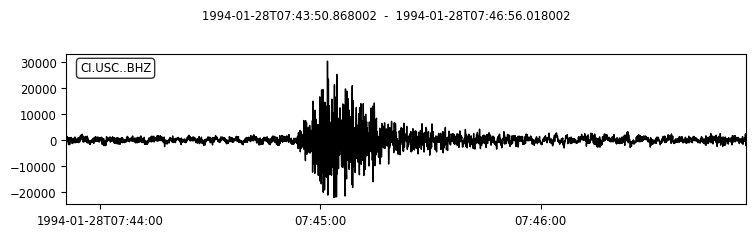

Processed 1 waveform traces


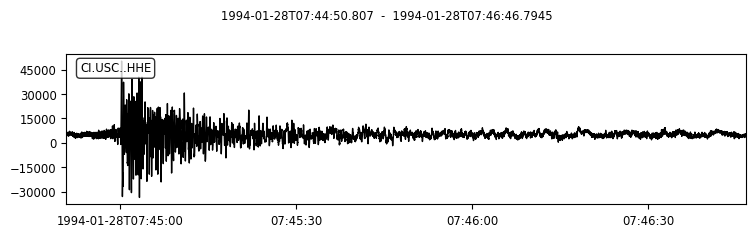

Processed 1 waveform traces


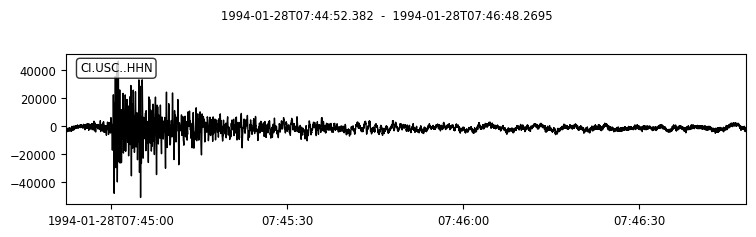

Processed 1 waveform traces


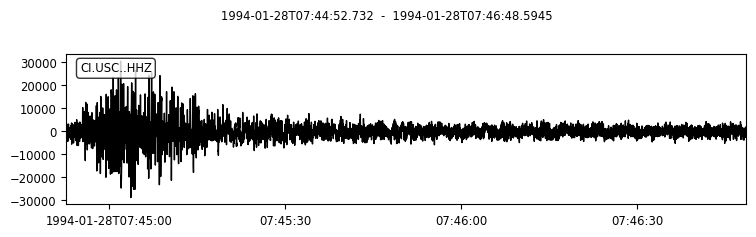

Processed 0 waveform traces
Processed 1 waveform traces


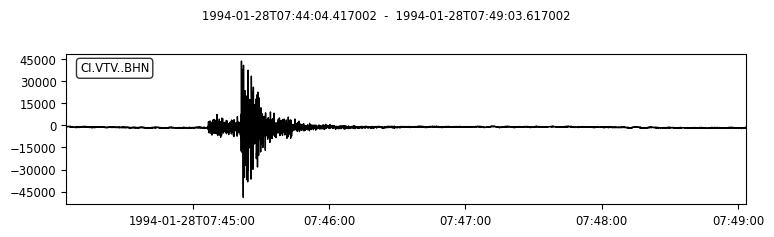

Processed 1 waveform traces


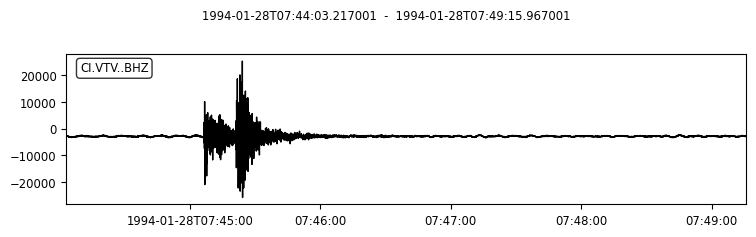

Processed 1 waveform traces


/home/vay3059/.local/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/home/vay3059/.local/lib/python3.12/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


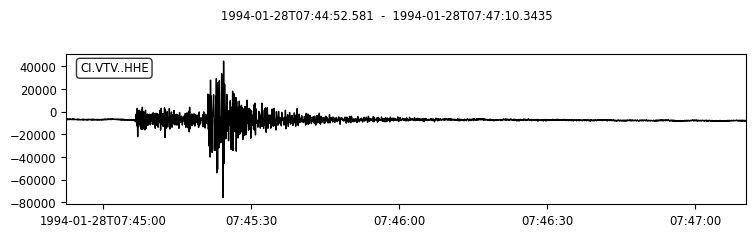

Processed 1 waveform traces


/home/vay3059/.local/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/home/vay3059/.local/lib/python3.12/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


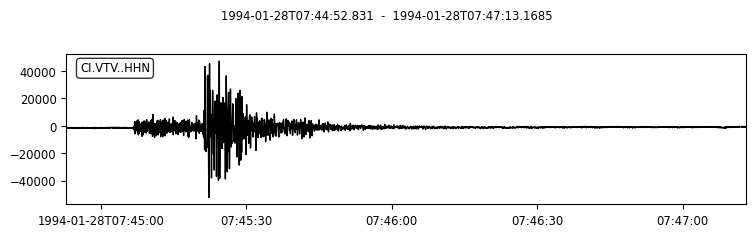

Processed 1 waveform traces


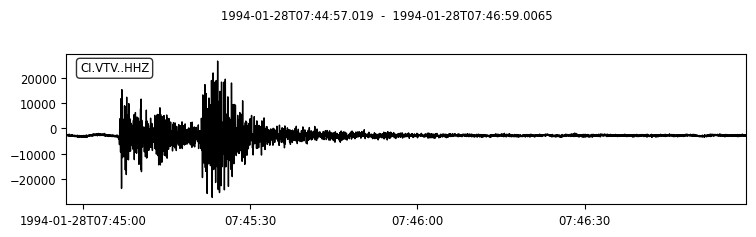

In [158]:
for station in test_stations:
    try:
        waveform = stp.get_trig(test_id, net=station[0], sta=station[1], chan=station[2])
    except:
        continue
    if len(waveform[test_id]) != 0:
        waveform[test_id].plot()

In [150]:
wmd_success_dict

# with open("raw_data.json", "w") as f:
#     json.dump(wmd_success_dict, f, indent=3)

{'2155068': [['CI',
   'CALB',
   'HHN',
   '--',
   'T',
   'A',
   '1994/03/22,13:07:26.642',
   '1.15m'],
  ['CI', 'CALB', 'HHZ', '--', 'T', 'A', '1994/03/22,13:07:27.604', '1.16m'],
  ['CI', 'CALB', 'HLE', '--', 'T', 'A', '1994/03/22,13:05:38.603', '3.63m'],
  ['CI', 'CALB', 'HLN', '--', 'T', 'A', '1994/03/22,13:06:43.653', '1.77m'],
  ['CI', 'CALB', 'HLZ', '--', 'T', 'A', '1994/03/22,13:07:09.953', '1.82m'],
  ['CI', 'CAV', 'EHZ', '--', 'T', 'A', '1994/03/22,13:06:39.680', '2.75m']],
 '3152388': [['CI',
   'CALB',
   'HHN',
   '--',
   'T',
   'A',
   '1994/02/15,04:10:38.900',
   '1.16m'],
  ['CI', 'CALB', 'HHZ', '--', 'T', 'A', '1994/02/15,04:10:41.124', '1.18m'],
  ['CI', 'CALB', 'HLE', '--', 'T', 'A', '1994/02/15,04:10:34.023', '1.69m'],
  ['CI', 'CALB', 'HLN', '--', 'T', 'A', '1994/02/15,04:10:14.773', '1.78m'],
  ['CI', 'CALB', 'HLZ', '--', 'T', 'A', '1994/02/15,04:09:50.023', '1.85m'],
  ['CI', 'CAV', 'EHZ', '--', 'T', 'A', '1994/02/15,04:10:36.330', '1.77m']],
 '3150936': 

In [95]:
waveform_metadata = stp.get_eavail(event_id, format='l', net='CI', as_list=True)

# store potentially useful metadata
seedids = [f"{w[0]}.{w[1]}.{w[3]}.{w[2]}" for w in waveform_metadata]
stations = set([w[1] for w in waveform_metadata])

In [96]:
pol_df = pd.read_csv('pol_worked.csv') # comparing with SKHASH stuff
to_match = pol_df[pol_df['event_id'] == event_id]

# get useful cols for seedid
match_net = to_match['network'].values
match_sta = to_match['station'].values
match_cha = to_match['channel'].values
match_loc = to_match['location'].values

# NOTE: match_combined is the set of seedids to get from the client
match_combined = []
for net, sta, loc, cha in zip(match_net, match_sta, match_loc, match_cha):
    combined = f"{net}.{sta}.{loc}.{cha}"
    match_combined.append(combined)
match_combined

['CI.IR2.--.VHZ',
 'CI.MWC.--.BHZ',
 'CI.SWM.--.EHZ',
 'CI.SIP.--.VHZ',
 'CI.SAD.--.EHZ',
 'CI.PTD.--.VHZ',
 'CI.GRH.--.ELZ',
 'CI.ECF.--.VHZ',
 'CI.SLG.--.EHZ',
 'CI.LRR.--.EHZ',
 'CI.BMT.--.VHZ',
 'CI.TPR.--.VHZ',
 'CI.LJB.--.EHZ',
 'CI.JNH.--.EHZ',
 'CI.OAK.--.VHZ',
 'CI.DBM.--.EHZ',
 'CI.WSP.--.EHZ',
 'CI.LEO.--.VHZ',
 'CI.LLN.--.EHZ',
 'CI.TWL.--.VHZ',
 'CI.STT.--.VHZ',
 'CI.TJR.--.VHZ',
 'CI.QAL.--.VHZ',
 'CI.CAL.--.VHZ',
 'CI.LHU.--.VHZ',
 'CI.CFL.--.ASZ',
 'CI.FOX.--.EHZ',
 'CI.SYL.--.ASZ',
 'CI.NHL.--.ASZ',
 'CI.PLS.--.VHZ',
 'CI.MNT.--.EHZ',
 'CI.BAL.--.EHZ',
 'CI.BLC.--.VHZ',
 'CI.VRD.--.EHZ']

In [49]:
match_sta

array(['IR2', 'MWC', 'SWM', 'SIP', 'SAD', 'PTD', 'GRH', 'ECF', 'SLG',
       'LRR', 'BMT', 'TPR', 'LJB', 'JNH', 'OAK', 'DBM', 'WSP', 'LEO',
       'LLN', 'TWL', 'STT', 'TJR', 'QAL', 'CAL', 'LHU', 'CFL', 'FOX',
       'SYL', 'NHL', 'PLS', 'MNT', 'BAL', 'BLC', 'VRD'], dtype=object)

In [50]:
filtered_seedids = list(set(seedids).intersection(set(match_combined)))
filtered_seedids

['CI.BAL.--.EHZ',
 'CI.LJB.--.EHZ',
 'CI.SLG.--.EHZ',
 'CI.VRD.--.EHZ',
 'CI.GRH.--.ELZ',
 'CI.SWM.--.EHZ',
 'CI.WSP.--.EHZ',
 'CI.JNH.--.EHZ',
 'CI.LLN.--.EHZ',
 'CI.MNT.--.EHZ',
 'CI.LRR.--.EHZ',
 'CI.FOX.--.EHZ',
 'CI.SAD.--.EHZ',
 'CI.DBM.--.EHZ']

In [61]:
test_seedid = filtered_seedids[len(filtered_seedids)-1]
test_net, test_sta, test_loc, test_cha = test_seedid.split('.')
waveforms = stp.get_trig([event_id], net=test_net, sta=test_sta)
type(list(waveforms.items())[0][1])

Processed 0 waveform traces


IndexError: Empty stream object

In [ ]:
for id in seedids:
    net, sta, loc, cha = id.split('.')
    stp.get_trig(event_id, net=net, sta=sta)
    

In [3]:
# set client for downloading waveforms
client = Client("SCEDC")
event_id = 2155068
event = client.get_events(eventid=str(event_id))[0]
print(event)

Event:	1994-03-22T13:07:33.580000Z | +34.224, -118.603 | 2.3  Ml | manual

	            resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?eventid=2155068")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='CI', agency_uri=ResourceIdentifier(id="quakeml:doi.org/10.7909/C3WD3xH1"), creation_time=UTCDateTime(2002, 4, 11, 21, 46, 14), version='1')
	    preferred_origin_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?originid=555771")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?magnitudeid=926883")
	                   ---------
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [4]:
origin = event.origins[0]
origin_time = origin.time
lat = origin.latitude
lon = origin.longitude
magnitude = event.magnitudes[0].mag
starttime = origin_time - 600
endtime = origin_time + 600

catalog = client.get_events(starttime=starttime, endtime=endtime,
                            minmagnitude=magnitude-0.1, maxmagnitude=magnitude+0.1,
                            includearrivals=True)
print(catalog)

assert len(catalog) == 1, "Expected exactly one event in the catalog"
event1 = catalog[0]
print(event1)

1 Event(s) in Catalog:
1994-03-22T13:07:33.580000Z | +34.224, -118.603 | 2.3  Ml | manual
Event:	1994-03-22T13:07:33.580000Z | +34.224, -118.603 | 2.3  Ml | manual

	            resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?eventid=2155068")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='CI', agency_uri=ResourceIdentifier(id="quakeml:doi.org/10.7909/C3WD3xH1"), creation_time=UTCDateTime(2002, 4, 11, 21, 46, 14), version='1')
	    preferred_origin_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?originid=555771")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?magnitudeid=926883")
	                   ---------
	                  picks: 49 Elements
	             amplitudes: 17 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [5]:
event1.picks[0]

Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=9574067")
	              time: UTCDateTime(1994, 3, 22, 13, 7, 38, 720000) [uncertainty=0.06]
	       waveform_id: WaveformStreamID(network_code='CI', station_code='IR2', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'negative'
	   evaluation_mode: 'manual'
	 evaluation_status: 'final'
	     creation_info: CreationInfo(agency_id='CI', creation_time=UTCDateTime(2002, 4, 11, 21, 46, 14))

In [ ]:
pol_df = pd.read_csv('pol_worked.csv') # comparing with SKHASH stuff
to_match = pol_df[pol_df['event_id'] == event_id]

# get useful cols for seedid
match_net = to_match['network'].values
match_sta = to_match['station'].values
match_cha = to_match['channel'].values
match_loc = to_match['location'].values

# change all '--' to empty string
match_loc = np.where(match_loc == '--', '*', match_loc)
# combine net.sta.loc.cha

# NOTE: match_combined is the set of seedids to get from the client
match_combined = []
for net, sta, loc, cha in zip(match_net, match_sta, match_loc, match_cha):
    combined = f"{net}.{sta}.{loc}.{cha}"
    match_combined.append(combined)
len(match_combined)

34

In [96]:
stations

['AZ.BZN (Buzz Northerns Place, Anza, CA, USA)',
 'AZ.CRY (Cary Ranch, Anza, CA, USA)',
 'AZ.FRD (Ford Ranch, Anza, CA, USA)',
 'AZ.KNW (Keenwild Fire Station, Mountain Center, CA, USA)',
 'AZ.LVA2 (Lost Valley Scout Camp, CA, USA)',
 'AZ.PFO (Pinyon Flats Observatory, CA, USA)',
 'AZ.RDM (Red Mountain, Riverside Co, CA, USA)',
 'AZ.SND (Jim Saunders Place, Anza, CA, USA)',
 'AZ.TRO (Toro Peak, Riverside Co, CA, USA)',
 'AZ.WMC (Walmic Ranch, Anza, CA, USA)',
 'BK.ARC (Humboldt State University, Arcata, CA, USA)',
 'BK.BKS (Byerly Seismographic Vault, Berkeley, CA, USA)',
 'BK.CMB (Columbia College, Columbia, CA, USA)',
 'BK.FRI (Friant)',
 'BK.MHC (Lick Observatory, Mt. Hamiliton, CA, USA)',
 'BK.MIN (Mt. Lassen Park Hdqts, Mineral, CA, USA)',
 'BK.ORV (Oroville Dam, Oroville, CA, USA)',
 'BK.PKD1 (Haliburton House, Parkfield, CA, USA)',
 'BK.SAO (San Andreas Geophysical Obs., Hollister, CA, USA)',
 'BK.STAN (Stanford, CA, USA)',
 'BK.WDC (Whiskeytown Dam, Whiskeytown, CA, USA)',
 'BK

In [27]:
inventory = client.get_stations(
    starttime=starttime,
    endtime=endtime,
    level="channel"
)
inventory

Inventory created at 2026-06-05T18:23:19.000000Z
	Created by: SCEDC WEB SERVICE: fdsnws-station | version: 1.1
		    http://service.scedc.caltech.edu/fdsnws/station/1/query?start=1994-...
	Sending institution: SCEDC (SCEDC)
	Contains:
		Networks (10):
			AZ, BK, CE, CI, NC, NN, NP, PG, SN, WR
		Stations (1236):
			AZ.BZN (Buzz Northerns Place, Anza, CA, USA)
			AZ.CRY (Cary Ranch, Anza, CA, USA)
			AZ.FRD (Ford Ranch, Anza, CA, USA)
			AZ.KNW (Keenwild Fire Station, Mountain Center, CA, USA)
			AZ.LVA2 (Lost Valley Scout Camp, CA, USA)
			AZ.PFO (Pinyon Flats Observatory, CA, USA)
			AZ.RDM (Red Mountain, Riverside Co, CA, USA)
			AZ.SND (Jim Saunders Place, Anza, CA, USA)
			AZ.TRO (Toro Peak, Riverside Co, CA, USA)
			AZ.WMC (Walmic Ranch, Anza, CA, USA)
			BK.ARC (Humboldt State University, Arcata, CA, USA)
			BK.BKS (Byerly Seismographic Vault, Berkeley, CA, USA)
			BK.CMB (Columbia College, Columbia, CA, USA)
			BK.FRI (Friant)
			BK.MHC (Lick Observatory, Mt. Hamiliton, CA, USA)


In [40]:
channels = inventory.get_contents()['channels']
stations = inventory.get_contents()['stations']
networks = inventory.get_contents()['networks']
len(channels), len(stations), len(networks)

(4265, 1236, 10)

In [51]:
# split by space then first by . (stations)
by_station = [sta.split()[0].split('.')[1] for sta in stations
              if sta.split()[0].split('.')[0] == 'CI']
matched_stations = list(set(by_station).intersection(set(match_sta)))
print(len(matched_stations))
print(matched_stations)
matched_stations_df = to_match[to_match['station'].isin(matched_stations)]
matched_stations_df

33
['BLC', 'LEO', 'TWL', 'ECF', 'WSP', 'GRH', 'QAL', 'SLG', 'LHU', 'FOX', 'SYL', 'LLN', 'SAD', 'OAK', 'BAL', 'JNH', 'MNT', 'BMT', 'STT', 'PLS', 'MWC', 'LJB', 'DBM', 'TJR', 'PTD', 'NHL', 'VRD', 'LRR', 'CFL', 'SIP', 'SWM', 'IR2', 'CAL']


,event_id,station,network,location,channel,p_polarity,takeoff,takeoff_uncertainty,azimuth,azimuth_uncertainty
828,2155068,IR2,CI,--,VHZ,-1.0,54.954996,0.1,50.243883,0.1
829,2155068,MWC,CI,--,BHZ,1.0,70.909062,0.1,91.759623,0.1
830,2155068,SWM,CI,--,EHZ,1.0,71.282135,0.1,3.177273,0.1
831,2155068,SIP,CI,--,VHZ,1.0,40.843851,0.1,255.803963,0.1
832,2155068,SAD,CI,--,EHZ,-1.0,45.039629,0.1,194.675821,0.1
833,2155068,PTD,CI,--,VHZ,-1.0,60.102401,0.1,214.148351,0.1
834,2155068,GRH,CI,--,ELZ,1.0,26.882078,0.1,34.131628,0.1
835,2155068,ECF,CI,--,VHZ,1.0,70.247536,0.1,299.122279,0.1
836,2155068,SLG,CI,--,EHZ,-1.0,67.662835,0.1,250.949346,0.1
837,2155068,LRR,CI,--,EHZ,-1.0,74.089596,0.1,59.309086,0.1


In [54]:
# do by channel too
by_channel = [f"{chan.split()[0].split('.')[1]}.{chan.split()[0].split('.')[3]}"
              for chan in channels if chan.split()[0].split('.')[0] == 'CI']
match_sta_cha = [f"{sta}.{cha}" for sta, cha in zip(match_sta, match_cha)]
matched_channels = list(set(by_channel).intersection(set(match_sta_cha)))
print(len(matched_channels))
print(matched_channels)
# matched_channels_df use and operator to filter by both station and channel
matched_channels_df = to_match[to_match.apply(lambda row: f"{row['station']}.{row['channel']}" in matched_channels, axis=1)]
matched_channels_df

14
['DBM.EHZ', 'MNT.EHZ', 'SLG.EHZ', 'FOX.EHZ', 'SAD.EHZ', 'LRR.EHZ', 'GRH.ELZ', 'SWM.EHZ', 'LJB.EHZ', 'WSP.EHZ', 'JNH.EHZ', 'VRD.EHZ', 'LLN.EHZ', 'BAL.EHZ']


,event_id,station,network,location,channel,p_polarity,takeoff,takeoff_uncertainty,azimuth,azimuth_uncertainty
830,2155068,SWM,CI,--,EHZ,1.0,71.282135,0.1,3.177273,0.1
832,2155068,SAD,CI,--,EHZ,-1.0,45.039629,0.1,194.675821,0.1
834,2155068,GRH,CI,--,ELZ,1.0,26.882078,0.1,34.131628,0.1
836,2155068,SLG,CI,--,EHZ,-1.0,67.662835,0.1,250.949346,0.1
837,2155068,LRR,CI,--,EHZ,-1.0,74.089596,0.1,59.309086,0.1
840,2155068,LJB,CI,--,EHZ,-1.0,116.867927,0.1,60.828746,0.1
841,2155068,JNH,CI,--,EHZ,-1.0,74.618676,0.1,68.913903,0.1
843,2155068,DBM,CI,--,EHZ,-1.0,116.867927,0.1,15.818327,0.1
844,2155068,WSP,CI,--,EHZ,-1.0,65.566993,0.1,4.761872,0.1
846,2155068,LLN,CI,--,EHZ,-1.0,116.867927,0.1,68.694649,0.1


In [63]:
# go by picks
pick = event1.picks[0]
pick

Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=9574067")
	              time: UTCDateTime(1994, 3, 22, 13, 7, 38, 720000) [uncertainty=0.06]
	       waveform_id: WaveformStreamID(network_code='CI', station_code='IR2', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'negative'
	   evaluation_mode: 'manual'
	 evaluation_status: 'final'
	     creation_info: CreationInfo(agency_id='CI', creation_time=UTCDateTime(2002, 4, 11, 21, 46, 14))

In [60]:
event1.amplitudes[0]

Amplitude
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?ampid=3229515")
	 generic_amplitude: 0.00884
	              type: 'AML'
	          category: 'point'
	              unit: 'm'
	         method_id: ResourceIdentifier(id="smi:ci.anss.org/amp/WAS")
	       waveform_id: WaveformStreamID(network_code='CI', station_code='GRH', channel_code='ELZ', location_code='')
	      scaling_time: UTCDateTime(1994, 3, 22, 13, 7)
	    magnitude_hint: 'ML'
	   evaluation_mode: 'manual'
	 evaluation_status: 'final'

In [65]:
pick_seedids = []
for idx, pick in enumerate(event1.picks):
    if pick.phase_hint == 'P':
        sta = pick.waveform_id.station_code
        net = pick.waveform_id.network_code
        cha = pick.waveform_id.channel_code
        loc = pick.waveform_id.location_code
        seed_id = '.'.join([net, sta, loc, cha])
        pick_seedids.append(seed_id)
print(pick_seedids)

['CI.IR2..EHZ', 'CI.SBB..EHZ', 'CI.MWC..EHZ', 'CI.SWM..EHZ', 'WR.PYR..EHZ', 'CI.SIP..EHZ', 'CI.SAD..EHZ', 'CI.PTD..EHZ', 'CI.GRH..EHZ', 'CI.PEM..EHZ', 'CI.ECF..EHZ', 'CI.SLG..EHZ', 'CI.LRR..EHZ', 'CI.BMT..EHZ', 'LA.TPR..EHZ', 'CI.LJB..EHZ', 'CI.JNH..EHZ', 'CI.GFP..ELZ', 'CI.DTP..EHZ', 'CI.XTL..EHZ', 'CI.OAK..EHZ', 'CI.ELM..EHZ', 'CI.SND..EHZ', 'CI.HYS..EHZ', 'CI.DBM..EHZ', 'CI.WSP..EHZ', 'CI.LEO..EHZ', 'CI.LLN..EHZ', 'CI.TWL..EHZ', 'CI.STT..EHZ', 'CI.THC..EHZ', 'CI.FIL..EHZ', 'CI.TJR..EHZ', 'CI.QAL..EHZ', 'CI.CAL..EHZ', 'CI.LHU..EHZ', 'CI.CFL..EHZ', 'CI.FOX..EHZ', 'CI.SYL..EHZ', 'CI.NHL..EHZ', 'CI.PLS..EHZ', 'CI.MNT..EHZ', 'CI.VVD..EHZ', 'CI.BAL..EHZ', 'CI.BLC..EHZ', 'CI.VRD..EHZ']


In [70]:
pick_stations = [pick.waveform_id.station_code for pick in event1.picks if pick.phase_hint == 'P']
print(len(pick_stations),  pick_stations)

46 ['IR2', 'SBB', 'MWC', 'SWM', 'PYR', 'SIP', 'SAD', 'PTD', 'GRH', 'PEM', 'ECF', 'SLG', 'LRR', 'BMT', 'TPR', 'LJB', 'JNH', 'GFP', 'DTP', 'XTL', 'OAK', 'ELM', 'SND', 'HYS', 'DBM', 'WSP', 'LEO', 'LLN', 'TWL', 'STT', 'THC', 'FIL', 'TJR', 'QAL', 'CAL', 'LHU', 'CFL', 'FOX', 'SYL', 'NHL', 'PLS', 'MNT', 'VVD', 'BAL', 'BLC', 'VRD']


In [71]:
data_dict = defaultdict(list)

def to_number(polarity):
    if polarity == 'positive':
        return 1
    elif polarity == 'negative':
        return -1
    else:
        return 0

for idx, pick in enumerate(event1.picks):
    if idx % 10 == 0:
        print(f"Processing pick {idx}/{len(event1.picks)}")
    if pick.phase_hint == 'P':
        stat = pick.waveform_id.station_code
        net = pick.waveform_id.network_code
        chan = pick.waveform_id.channel_code
        loc = pick.waveform_id.location_code
        seed_id = '.'.join([net, stat, loc, chan])
        try:
            inventory = client.get_stations(starttime=pick.time, endtime=pick.time + 1,
                                            network=net, station=stat, channel=chan, level="channel")
        except Exception as e:
            print(f"Error occurred while fetching station information for {seed_id}")
            # print error message
            print(f"Error: {e}")
            continue
        
        try:
            coordinates = inventory.get_coordinates(seed_id)
        except Exception as e:
            print(f"Error occurred while fetching coordinates for {seed_id}")
            # print error message
            print(f"Error: {e}")
            continue
        
        if len(data_dict[seed_id]) == 0:
            data_dict[seed_id].extend(list(coordinates.values())[:2] + [to_number(pick.polarity)])

# collapse to sign
for seed_id in data_dict:
    if abs(data_dict[seed_id][2]) > 1: print(f"{seed_id} has polarity {data_dict[seed_id][2]}")
    data_dict[seed_id][2] = np.sign(data_dict[seed_id][2])

Processing pick 0/49
Error occurred while fetching coordinates for WR.PYR..EHZ
Error: No matching channel metadata found.
Processing pick 10/49
Error occurred while fetching station information for LA.TPR..EHZ
Error: No data available for request.
HTTP Status code: 204
Detailed response of server:


Processing pick 20/49
Processing pick 30/49
Processing pick 40/49


In [77]:
# NOTE: get event location
lat = event1.origins[0].latitude
lon = event1.origins[0].longitude
hdepth = event1.origins[0].depth/1000 # convert to km

col_string = 'event_id, station, network, location, channel, p_polarity, takeoff, takeoff_uncertainty, azimuth, azimuth_uncertainty'
columns = [col.strip() for col in col_string.split(',')]
df = pd.DataFrame(columns=columns)
takeoff_unc = 0.1 # placeholder
az_unc = 0.1 # placeholder
epdists = []
 
velocity_model = TauPyModel(model='ak135')
# velocity_model = TauPyModel(model='iasp91')

for key, value in data_dict.items():
    net, stat, loc, chan = key.split('.')
    p_polarity = value[2]
    src2dst = [lat, lon, value[0], value[1]]
    dist, az, baz = gps2dist_azimuth(*src2dst)
    epdist = kilometers2degrees(dist / 1000) # convert to km
    
    try:
        print()
        print(f"INPUTS:\n{hdepth} km depth, {epdist:.2f} degrees distance")
        p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                            distance_in_degree=epdist, phase_list=['P', 'p'])
                            # phase_list=['P', 'Pn', 'Pg'])
        print(f"OUTPUTS:")
        for arrival in p_arrivals:
            print(f"Phase: {arrival.phase.name}, Time: {arrival.time:.2f} s, Takeoff angle: {arrival.takeoff_angle:.2f} degrees")
        print()
    except Exception as e:
        print(f"Error occurred while calculating travel times for station {stat}")
        # print error message
        print(f"Error: {e}")
        continue
    
    if len(p_arrivals) == 0:
        print(f"Station {stat} has no P arrival. Skipping.")
        print(f"Epidist = {epdist:.2f} degrees, depth = {hdepth} km")
        continue
    
    epdists.append(epdist)
    takeoff = p_arrivals[0].takeoff_angle
    takeoff = 180 - takeoff # convert to angle from vertical (SKHASH convention)
    
    if p_polarity != 0:
        df.loc[len(df)] = [event_id, stat, net, loc, chan, float(p_polarity),
                        takeoff, takeoff_unc, az, az_unc]
    else: print(f"Station {stat} has zero polarity. Skipping.")


INPUTS:
19.368 km depth, 0.23 degrees distance
OUTPUTS:
Phase: p, Time: 5.60 s, Takeoff angle: 126.50 degrees


INPUTS:
19.368 km depth, 0.79 degrees distance
OUTPUTS:
Phase: P, Time: 15.13 s, Takeoff angle: 63.15 degrees
Phase: p, Time: 15.53 s, Takeoff angle: 102.02 degrees
Phase: P, Time: 15.58 s, Takeoff angle: 77.15 degrees
Phase: P, Time: 16.09 s, Takeoff angle: 46.02 degrees
Phase: P, Time: 16.29 s, Takeoff angle: 52.99 degrees

Station SBB has zero polarity. Skipping.

INPUTS:
19.368 km depth, 0.45 degrees distance
OUTPUTS:
Phase: p, Time: 9.26 s, Takeoff angle: 110.91 degrees
Phase: P, Time: 9.31 s, Takeoff angle: 63.15 degrees
Phase: P, Time: 9.34 s, Takeoff angle: 67.82 degrees


INPUTS:
19.368 km depth, 0.49 degrees distance
OUTPUTS:
Phase: p, Time: 9.98 s, Takeoff angle: 109.31 degrees
Phase: P, Time: 9.99 s, Takeoff angle: 63.15 degrees
Phase: P, Time: 10.05 s, Takeoff angle: 69.49 degrees


INPUTS:
19.368 km depth, 0.15 degrees distance
OUTPUTS:
Phase: p, Time: 4.39 s, 

In [78]:
df.to_csv('pol_2155068.csv', index=False)

In [95]:
event1.picks[0]

Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=9574067")
	              time: UTCDateTime(1994, 3, 22, 13, 7, 38, 720000) [uncertainty=0.06]
	       waveform_id: WaveformStreamID(network_code='CI', station_code='IR2', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'negative'
	   evaluation_mode: 'manual'
	 evaluation_status: 'final'
	     creation_info: CreationInfo(agency_id='CI', creation_time=UTCDateTime(2002, 4, 11, 21, 46, 14))

In [86]:
client

FDSN Webservice Client (base url: http://service.scedc.caltech.edu)
Available Services: 'dataselect' (v1.1.0), 'event' (v1.1.1), 'station' (v1.1.0), 'available_event_catalogs', 'available_event_contributors'

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.

In [92]:
t = UTCDateTime("2021-03-22T13:07:38")

st = client.get_waveforms(
    network="CI",
    station="IR2",
    location="--",
    channel="EHZ",
    starttime=starttime,
    endtime=endtime
)

st.plot()

FDSNNoDataException: No data available for request.
HTTP Status code: 204
Detailed response of server:



In [67]:
net, sta, loc, cha = pick_seedids[0].split('.')
# get waveform data for this seedid

waveform = client.get_waveforms(network=net, station=sta, location=loc, channel=cha,
                                starttime=starttime, endtime=endtime)

FDSNNoDataException: No data available for request.
HTTP Status code: 204
Detailed response of server:

